# 02 — Feature Engineering & Selection

**Goal:** Load cleaned data, engineer domain-informed features,
analyse correlations, select final feature set, save for modelling.

**Input:**  `data/processed/01_cleaned.parquet`
**Output:** `data/processed/02_features.parquet`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries loaded ")

Libraries loaded 


In [3]:
# load cleaned dataset

df_clean = pd.read_parquet('../data/processed/01_cleaned.parquet')
print("Loaded cleaned data ✅")
print(f"Shape: {df_clean.shape}")
df_clean.head()

Loaded cleaned data ✅
Shape: (196304, 15)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time_minutes
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,american,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,american,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51.250000
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,american,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333


### Feature Group 1: Time Features

Extract temporal signals from order timestamp.
Delivery time varies significantly by hour, day, and whether
the order falls within peak demand windows.

In [4]:
df_clean['hour'] = df_clean['created_at'].dt.hour
df_clean['day_of_week'] = df_clean['created_at'].dt.dayofweek
df_clean['is_weekend'] = (
    df_clean['day_of_week'].isin([5, 6]).astype(int)
)
df_clean['is_peak_hour'] = (
    df_clean['hour'].isin([7,8,9,12,13,18,19,20]).astype(int)
)
df_clean['is_night'] = (
    df_clean['hour'].isin([22,23,0,1,2,3]).astype(int)
)

print("Time features created ✅")
print(df_clean[['created_at','hour','day_of_week',
                'is_weekend','is_peak_hour','is_night']].head())

Time features created ✅
           created_at  hour  day_of_week  is_weekend  is_peak_hour  is_night
0 2015-02-06 22:24:17    22            4           0             0         1
1 2015-02-10 21:49:25    21            1           0             0         0
2 2015-01-22 20:39:28    20            3           0             1         0
3 2015-02-03 21:21:45    21            1           0             0         0
4 2015-02-15 02:40:36     2            6           1             0         1


### Feature Group 2: Partner Pressure Features

Capture real-time delivery partner workload.
High utilisation = fewer available partners = longer wait times.

In [5]:
df_clean['partner_utilisation'] = np.where(
    df_clean['total_onshift_partners'] > 0,
    df_clean['total_busy_partners'] / df_clean['total_onshift_partners'],
    0
).clip(0, 1)

df_clean['orders_per_partner'] = np.where(
    df_clean['total_onshift_partners'] > 0,
    df_clean['total_outstanding_orders'] / df_clean['total_onshift_partners'],
    0
)

df_clean['available_partners'] = (
    df_clean['total_onshift_partners'] - df_clean['total_busy_partners']
).clip(0, None)

print("Partner features created ✅")
print(df_clean[['partner_utilisation',
                'orders_per_partner',
                'available_partners']].describe())

Partner features created ✅
       partner_utilisation  orders_per_partner  available_partners
count        196304.000000       196304.000000       196304.000000
mean              0.873373            1.185622            4.705335
std               0.195013            0.473605            8.362968
min               0.000000           -3.000000            0.000000
25%               0.833333            0.950000            0.000000
50%               0.942308            1.147059            2.000000
75%               1.000000            1.436364            5.000000
max               1.000000           47.000000           86.000000


### Feature Group 3: Order Complexity Features

Capture order difficulty signals.
Higher value orders and wider price ranges indicate
more complex orders requiring longer preparation.

In [6]:
df_clean['price_spread'] = (
    df_clean['max_item_price'] - df_clean['min_item_price']
)

df_clean['avg_item_price'] = (
    df_clean['subtotal'] / df_clean['total_items']
)

df_clean['diversity_ratio'] = np.where(
    df_clean['total_items'] > 1,
    df_clean['num_distinct_items'] / df_clean['total_items'],
    1.0
)

df_clean['is_single_item'] = (
    df_clean['total_items'] == 1
).astype(int)

print("Order complexity features created ✅")
print(df_clean[['price_spread','avg_item_price',
                'diversity_ratio','is_single_item']].head())

Order complexity features created ✅
   price_spread  avg_item_price  diversity_ratio  is_single_item
0           682          860.25         1.000000               0
1             0         1900.00         1.000000               1
2             0         1900.00         1.000000               1
3          1200         1150.00         0.833333               0
4           500         1300.00         1.000000               0


### Correlation Analysis

Measure linear relationship between each feature and target.
Guides initial feature selection before SHAP-based validation.

In [7]:
feature_cols = [
    'market_id', 'order_protocol', 'total_items', 'subtotal',
    'num_distinct_items', 'min_item_price', 'max_item_price',
    'total_onshift_partners', 'total_busy_partners',
    'total_outstanding_orders', 'hour', 'day_of_week',
    'is_weekend', 'is_peak_hour', 'is_night',
    'partner_utilisation', 'orders_per_partner', 'available_partners',
    'price_spread', 'avg_item_price', 'diversity_ratio', 'is_single_item',
]
target_col = 'delivery_time_minutes'

corr_df = df_clean[feature_cols + [target_col]].corr()

target_corr = (corr_df[target_col]
               .drop(target_col)
               .sort_values(ascending=False))

print("Correlation with delivery_time_minutes:")
print(target_corr)

Correlation with delivery_time_minutes:
orders_per_partner          0.286663
subtotal                    0.228515
total_outstanding_orders    0.191077
is_night                    0.179656
num_distinct_items          0.165142
max_item_price              0.141612
price_spread                0.136299
total_items                 0.123578
partner_utilisation         0.103902
total_busy_partners         0.102459
avg_item_price              0.083855
total_onshift_partners      0.082225
is_weekend                  0.072862
min_item_price              0.016655
day_of_week                 0.010786
diversity_ratio            -0.023799
market_id                  -0.046319
available_partners         -0.074627
order_protocol             -0.074959
is_peak_hour               -0.081527
is_single_item             -0.088851
hour                       -0.177149
Name: delivery_time_minutes, dtype: float64


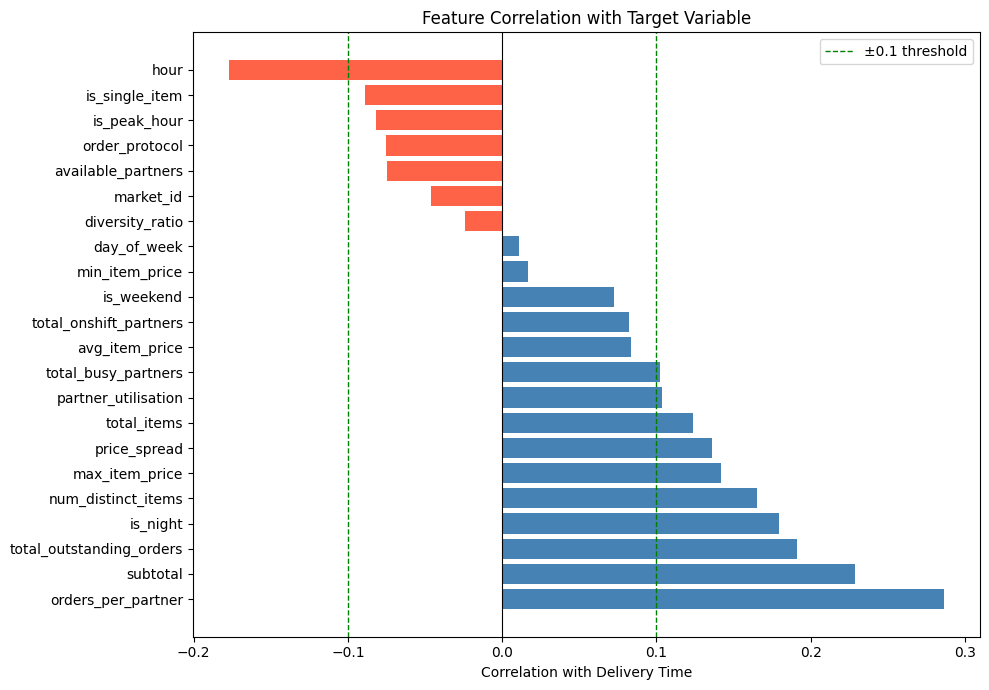

In [8]:
# correlaation barplot

plt.figure(figsize=(10, 7))
colors = ['steelblue' if x > 0 else 'tomato' for x in target_corr.values]

plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.axvline(x=0.1, color='green', linewidth=1,
            linestyle='--', label='±0.1 threshold')
plt.axvline(x=-0.1, color='green', linewidth=1, linestyle='--')
plt.xlabel('Correlation with Delivery Time')
plt.title('Feature Correlation with Target Variable')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Selection

Drop raw partner columns (replaced by engineered versions),
near-zero correlation features, and non-predictive identifiers.

In [9]:
cols_to_drop = [
    'total_busy_partners',
    'total_onshift_partners',
    'total_outstanding_orders',
    'min_item_price',
    'day_of_week',
    'diversity_ratio',
    'store_id',
    'store_primary_category',
    'created_at',
    'actual_delivery_time',
]

df_model = df_clean.drop(columns=cols_to_drop)

X = df_model.drop(columns=['delivery_time_minutes'])
y = df_model['delivery_time_minutes']

print(f"Final features: {len(X.columns)}")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Final features: 16
  1. market_id
  2. order_protocol
  3. total_items
  4. subtotal
  5. num_distinct_items
  6. max_item_price
  7. hour
  8. is_weekend
  9. is_peak_hour
  10. is_night
  11. partner_utilisation
  12. orders_per_partner
  13. available_partners
  14. price_spread
  15. avg_item_price
  16. is_single_item


In [11]:
# Save full modelling dataframe
df_model.to_parquet(
    '../data/processed/02_features.parquet',
    index=False
)
print("Feature data saved to data/processed/02_features.parquet")
print(f"   Shape: {df_model.shape}")

Feature data saved to data/processed/02_features.parquet
   Shape: (196304, 17)


## Feature Engineering Summary

Created 9 engineered features across 3 groups:

**Time:** hour, is_weekend, is_peak_hour, is_night
**Partner:** partner_utilisation, orders_per_partner, available_partners
**Order:** price_spread, avg_item_price, is_single_item

Dropped 10 redundant/weak columns.
Final feature set: 16 features → saved to `data/processed/02_features.parquet`